# User Risk Profiling — EDA

Análisis exploratorio de los tres datasets del challenge de seguridad de datos.

**Datasets:**
- `user_inventory.csv` — 500 usuarios
- `permission_inventory.csv` — 2,944 permisos
- `access_logs.csv` — 20,495 eventos de acceso

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

DATA_RAW = Path('../data/01_raw')

In [3]:
users = pd.read_csv(DATA_RAW / 'user_inventory.csv', parse_dates=['created_at'])
perms = pd.read_csv(DATA_RAW / 'permission_inventory.csv', parse_dates=['assigned_at', 'expires_at'])
logs  = pd.read_csv(DATA_RAW / 'access_logs.csv', parse_dates=['timestamp'])

# Orden nominal para criticidad
CRIT_ORDER = ['LOW', 'MEDIUM', 'HIGH', 'VERY_HIGH']
CRIT_DTYPE = pd.CategoricalDtype(categories=CRIT_ORDER, ordered=True)
perms['criticality'] = perms['criticality'].astype(CRIT_DTYPE)

REFERENCE_DATE = logs['timestamp'].max()
print(f'Fecha de referencia (último evento): {REFERENCE_DATE}')
print(f'users: {users.shape} | perms: {perms.shape} | logs: {logs.shape}')

Fecha de referencia (último evento): 2026-05-26 19:53:01
users: (500, 7) | perms: (2944, 6) | logs: (20495, 7)


---
## 1. Calidad de datos

### 1.1 Valores nulos

In [4]:
def nulls_summary(df, name):
    s = df.isnull().sum()
    s = s[s > 0]
    if s.empty:
        print(f'{name}: sin nulos')
        return
    pct = (s / len(df) * 100).round(1)
    print(f'\n{name}:')
    print(pd.DataFrame({'nulos': s, '%': pct}).to_string())

nulls_summary(users, 'user_inventory')
nulls_summary(perms, 'permission_inventory')
nulls_summary(logs,  'access_logs')


user_inventory:
            nulos     %
manager_id     50  10.0

permission_inventory:
            nulos     %
expires_at   2004  68.1
access_logs: sin nulos


### 1.2 Duplicados

In [4]:
for df, name in [(users, 'user_inventory'), (perms, 'permission_inventory'), (logs, 'access_logs')]:
    dups = df.duplicated().sum()
    print(f'{name}: {dups} filas duplicadas ({dups/len(df)*100:.1f}%)')

user_inventory: 0 filas duplicadas (0.0%)
permission_inventory: 0 filas duplicadas (0.0%)
access_logs: 0 filas duplicadas (0.0%)


### 1.3 Integridad referencial

In [5]:
known_users = set(users['user_id'])
known_resources = set(perms['resource_id'])

logs_unknown_users = logs[~logs['user_id'].isin(known_users)]
logs_unknown_resources = logs[~logs['resource_id'].isin(known_resources)]
perms_unknown_users = perms[~perms['user_id'].isin(known_users)]

print(f'Accesos de usuarios no registrados en user_inventory: {len(logs_unknown_users)} ({logs_unknown_users["user_id"].nunique()} únicos)')
print(f'Accesos a recursos sin permiso registrado:            {len(logs_unknown_resources)} ({logs_unknown_resources["resource_id"].nunique()} únicos)')
print(f'Permisos de usuarios no registrados en user_inventory: {len(perms_unknown_users)}')

Accesos de usuarios no registrados en user_inventory: 0 (0 únicos)
Accesos a recursos sin permiso registrado:            0 (0 únicos)
Permisos de usuarios no registrados en user_inventory: 0


### 1.4 Rangos temporales

In [6]:
print('=== user_inventory.created_at ===')
print(f'  min: {users["created_at"].min()}  max: {users["created_at"].max()}')

print('\n=== permission_inventory ===')
print(f'  assigned_at min: {perms["assigned_at"].min()}  max: {perms["assigned_at"].max()}')
print(f'  expires_at  min: {perms["expires_at"].min()}  max: {perms["expires_at"].max()}')

print('\n=== access_logs.timestamp ===')
print(f'  min: {logs["timestamp"].min()}  max: {logs["timestamp"].max()}')

# Permisos donde expires_at < assigned_at (inconsistencia)
bad_dates = perms.dropna(subset=['expires_at'])
bad_dates = bad_dates[bad_dates['expires_at'] < bad_dates['assigned_at']]
print(f'\nPermisos con expires_at < assigned_at (inconsistencia): {len(bad_dates)}')

=== user_inventory.created_at ===
  min: 2024-11-02 00:00:00  max: 2025-10-31 00:00:00

=== permission_inventory ===
  assigned_at min: 2024-11-03 00:00:00  max: 2025-11-30 00:00:00
  expires_at  min: 2025-12-01 00:00:00  max: 2026-11-22 00:00:00

=== access_logs.timestamp ===
  min: 2025-11-01 08:00:01  max: 2026-05-26 19:53:01

Permisos con expires_at < assigned_at (inconsistencia): 0


---
## 2. User Inventory

### 2.1 Tipo de usuario y estado

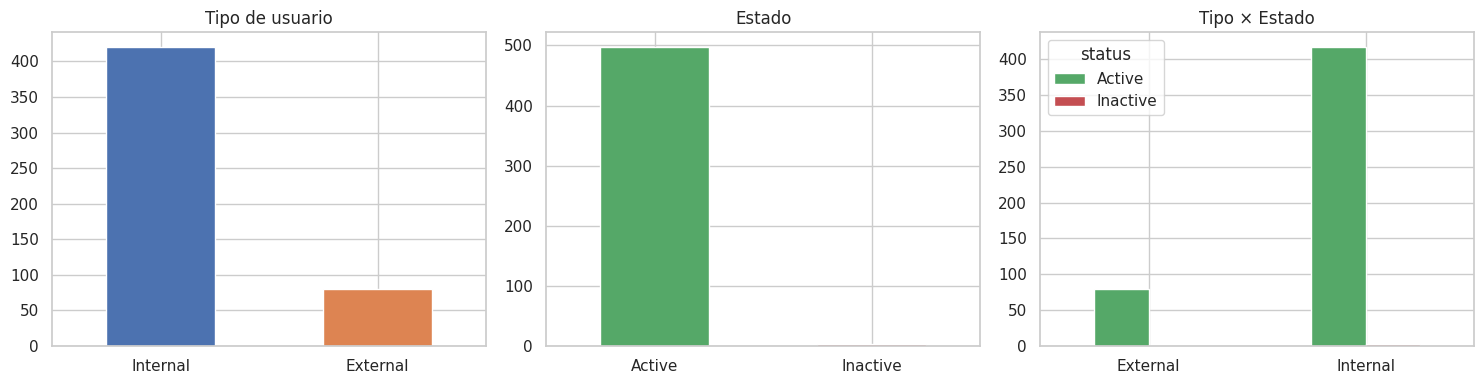

status     Active  Inactive  All
user_type                       
External       80         0   80
Internal      417         3  420
All           497         3  500


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

users['user_type'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Tipo de usuario')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

users['status'].value_counts().plot(kind='bar', ax=axes[1], color=['#55A868', '#C44E52'])
axes[1].set_title('Estado')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

ct = pd.crosstab(users['user_type'], users['status'])
ct.plot(kind='bar', ax=axes[2], color=['#55A868', '#C44E52'])
axes[2].set_title('Tipo × Estado')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(pd.crosstab(users['user_type'], users['status'], margins=True))

### 2.2 Departamento y rol

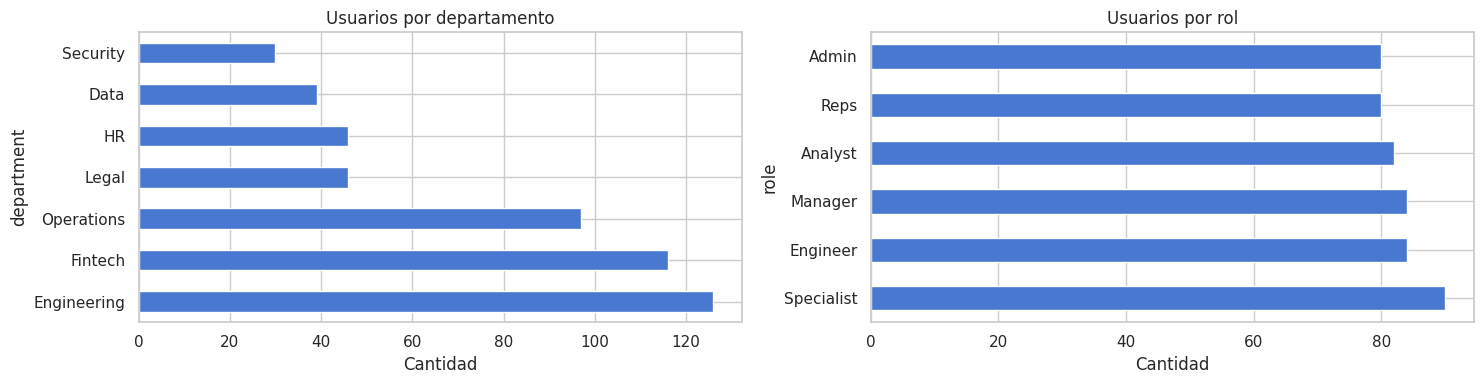


Departamento × Rol (heatmap):


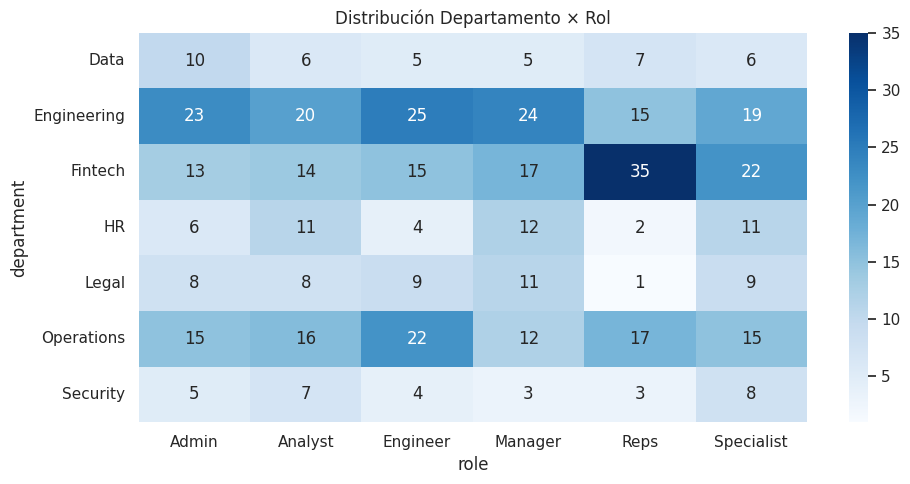

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

users['department'].value_counts().plot(kind='barh', ax=axes[0])
axes[0].set_title('Usuarios por departamento')
axes[0].set_xlabel('Cantidad')

users['role'].value_counts().plot(kind='barh', ax=axes[1])
axes[1].set_title('Usuarios por rol')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

print('\nDepartamento × Rol (heatmap):')
ct_dept_role = pd.crosstab(users['department'], users['role'])
plt.figure(figsize=(10, 5))
sns.heatmap(ct_dept_role, annot=True, fmt='d', cmap='Blues')
plt.title('Distribución Departamento × Rol')
plt.tight_layout()
plt.show()

### 2.3 Antigüedad de cuentas

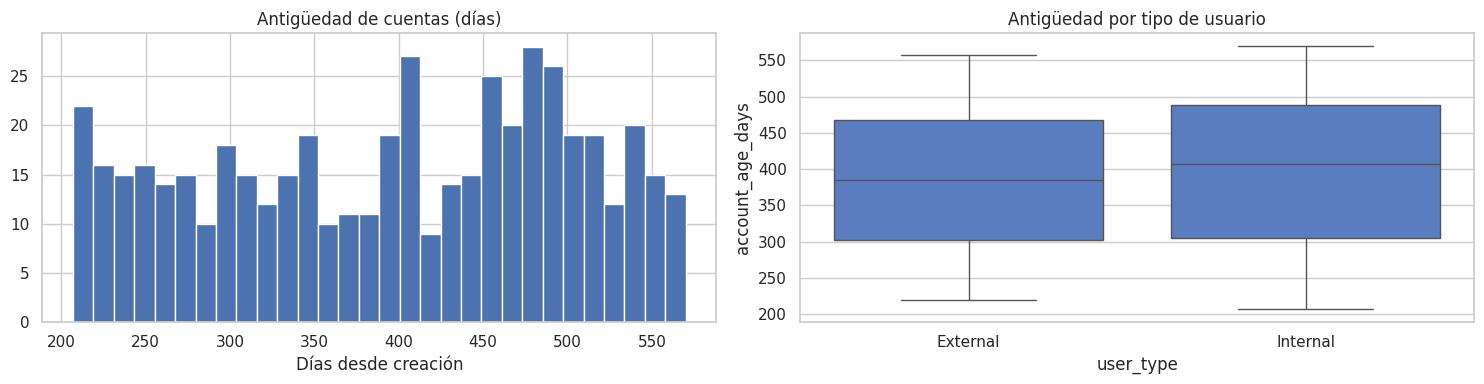

           count   mean    std    min    25%    50%    75%    max
user_type                                                        
External    80.0  384.1   97.5  219.0  302.8  385.5  468.0  557.0
Internal   420.0  397.4  106.1  207.0  305.2  407.5  488.0  570.0


In [9]:
users['account_age_days'] = (REFERENCE_DATE - users['created_at']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(users['account_age_days'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Antigüedad de cuentas (días)')
axes[0].set_xlabel('Días desde creación')

sns.boxplot(data=users, x='user_type', y='account_age_days', ax=axes[1])
axes[1].set_title('Antigüedad por tipo de usuario')

plt.tight_layout()
plt.show()

print(users.groupby('user_type')['account_age_days'].describe().round(1))

### 2.4 Usuarios sin manager (posibles cuentas huérfanas)

In [10]:
no_manager = users[users['manager_id'].isna()]
print(f'Usuarios sin manager: {len(no_manager)} ({len(no_manager)/len(users)*100:.1f}%)')
print('Breakdown por tipo y rol:')
print(no_manager.groupby(['user_type', 'role']).size().reset_index(name='count').to_string(index=False))

Usuarios sin manager: 50 (10.0%)
Breakdown por tipo y rol:
user_type       role  count
 External       Reps     11
 Internal      Admin      5
 Internal    Analyst     12
 Internal   Engineer      7
 Internal    Manager      7
 Internal Specialist      8


---
## 3. Permission Inventory

### 3.1 Permisos por usuario

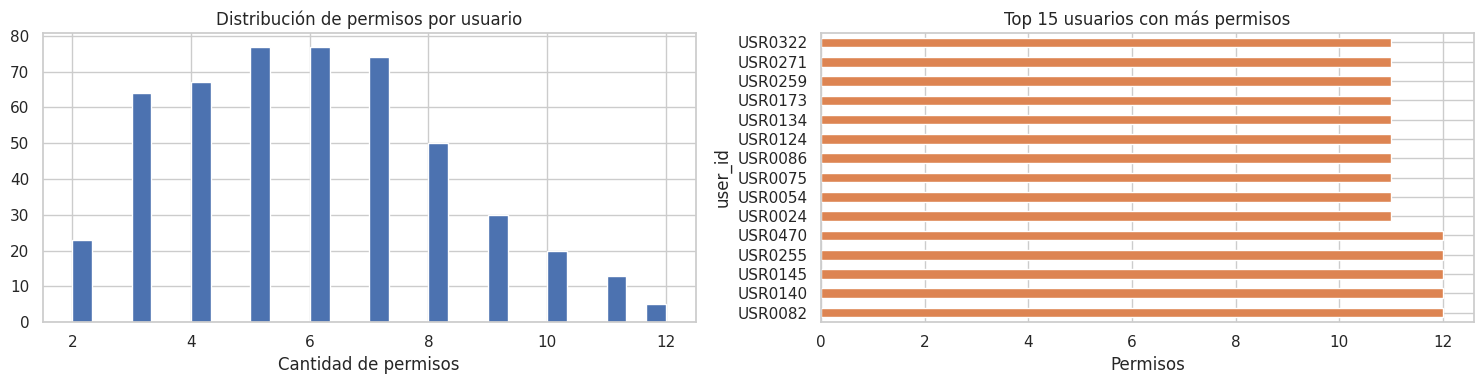

count    500.0
mean       5.9
std        2.3
min        2.0
25%        4.0
50%        6.0
75%        7.0
max       12.0
dtype: float64


In [11]:
perms_per_user = perms.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(perms_per_user, bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de permisos por usuario')
axes[0].set_xlabel('Cantidad de permisos')

top_n = perms_per_user.nlargest(15)
top_n.plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Top 15 usuarios con más permisos')
axes[1].set_xlabel('Permisos')

plt.tight_layout()
plt.show()

print(perms_per_user.describe().round(1))

### 3.2 Distribución por tipo de recurso y criticidad

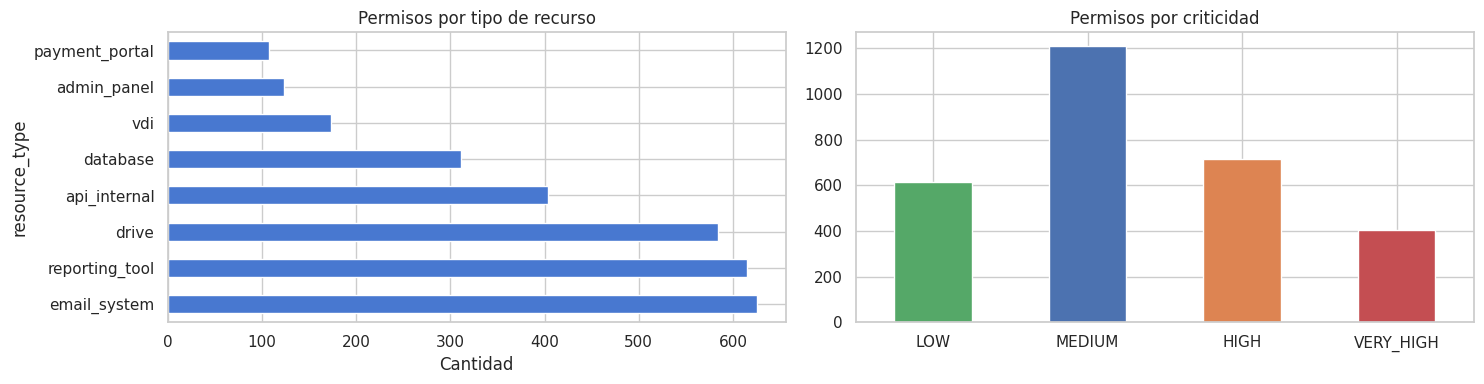

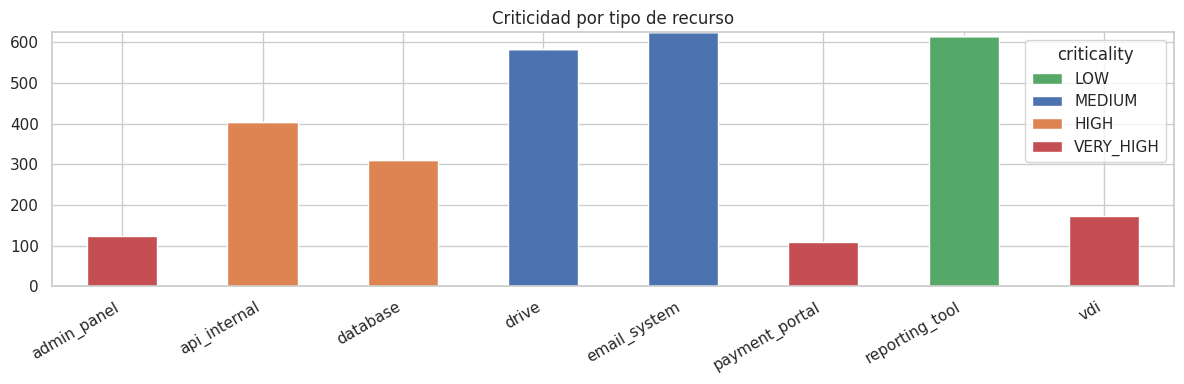

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

perms['resource_type'].value_counts().plot(kind='barh', ax=axes[0])
axes[0].set_title('Permisos por tipo de recurso')
axes[0].set_xlabel('Cantidad')

perms['criticality'].value_counts().reindex(CRIT_ORDER).plot(kind='bar', ax=axes[1],
    color=['#55A868', '#4C72B0', '#DD8452', '#C44E52'])
axes[1].set_title('Permisos por criticidad')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Criticidad por tipo de recurso
ct = pd.crosstab(perms['resource_type'], perms['criticality'])[CRIT_ORDER]
ct.plot(kind='bar', stacked=True, figsize=(12, 4),
        color=['#55A868', '#4C72B0', '#DD8452', '#C44E52'])
plt.title('Criticidad por tipo de recurso')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 3.3 Permisos expirados

In [13]:
perms_with_exp = perms.dropna(subset=['expires_at'])
expired = perms_with_exp[perms_with_exp['expires_at'] < REFERENCE_DATE]
no_exp = perms[perms['expires_at'].isna()]

print(f'Total permisos:                  {len(perms):>6}')
print(f'Sin fecha de expiración (null):  {len(no_exp):>6} ({len(no_exp)/len(perms)*100:.1f}%)')
print(f'Con expiración futura:           {len(perms_with_exp) - len(expired):>6}')
print(f'EXPIRADOS (expires_at < hoy):    {len(expired):>6} ({len(expired)/len(perms)*100:.1f}%)')

print('\nExpirados por criticidad:')
print(expired['criticality'].value_counts().reindex(CRIT_ORDER).dropna())

print('\nExpirados por tipo de recurso:')
print(expired['resource_type'].value_counts())

Total permisos:                    2944
Sin fecha de expiración (null):    2004 (68.1%)
Con expiración futura:              926
EXPIRADOS (expires_at < hoy):        14 (0.5%)

Expirados por criticidad:
criticality
LOW          2
MEDIUM       2
HIGH         6
VERY_HIGH    4
Name: count, dtype: int64

Expirados por tipo de recurso:
resource_type
api_internal      4
vdi               3
reporting_tool    2
database          2
admin_panel       1
drive             1
email_system      1
Name: count, dtype: int64


### 3.4 Usuarios inactivos con permisos activos (señal de riesgo)

In [14]:
inactive_users = set(users[users['status'] == 'Inactive']['user_id'])
active_perms = perms[(perms['expires_at'].isna()) | (perms['expires_at'] >= REFERENCE_DATE)]

inactive_with_active_perms = active_perms[active_perms['user_id'].isin(inactive_users)]

print(f'Usuarios inactivos:                             {len(inactive_users)}')
print(f'Usuarios inactivos con permisos activos:        {inactive_with_active_perms["user_id"].nunique()}')
print(f'Total permisos activos en usuarios inactivos:   {len(inactive_with_active_perms)}')
print('\nBreakdown por criticidad:')
print(inactive_with_active_perms['criticality'].value_counts().reindex(CRIT_ORDER).dropna())

Usuarios inactivos:                             3
Usuarios inactivos con permisos activos:        3
Total permisos activos en usuarios inactivos:   15

Breakdown por criticidad:
criticality
LOW          3
MEDIUM       4
HIGH         4
VERY_HIGH    4
Name: count, dtype: int64


---
## 4. Access Logs

### 4.1 Volumen de accesos por usuario

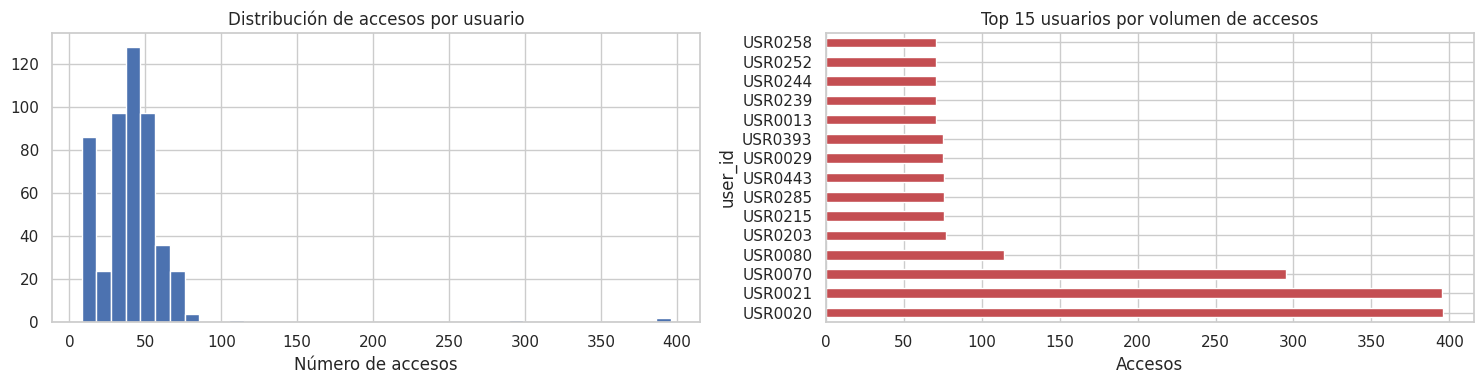

count    500.0
mean      41.0
std       30.3
min        8.0
25%       29.0
50%       41.0
75%       50.0
max      396.0
dtype: float64

Usuarios sin ningún acceso en logs: 0


In [15]:
accesses_per_user = logs.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(accesses_per_user, bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de accesos por usuario')
axes[0].set_xlabel('Número de accesos')

top_users = accesses_per_user.nlargest(15)
top_users.plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('Top 15 usuarios por volumen de accesos')
axes[1].set_xlabel('Accesos')

plt.tight_layout()
plt.show()

print(accesses_per_user.describe().round(1))

# Usuarios sin ningún acceso registrado
users_without_logs = known_users - set(logs['user_id'])
print(f'\nUsuarios sin ningún acceso en logs: {len(users_without_logs)}')

### 4.2 Distribución de acciones y recursos

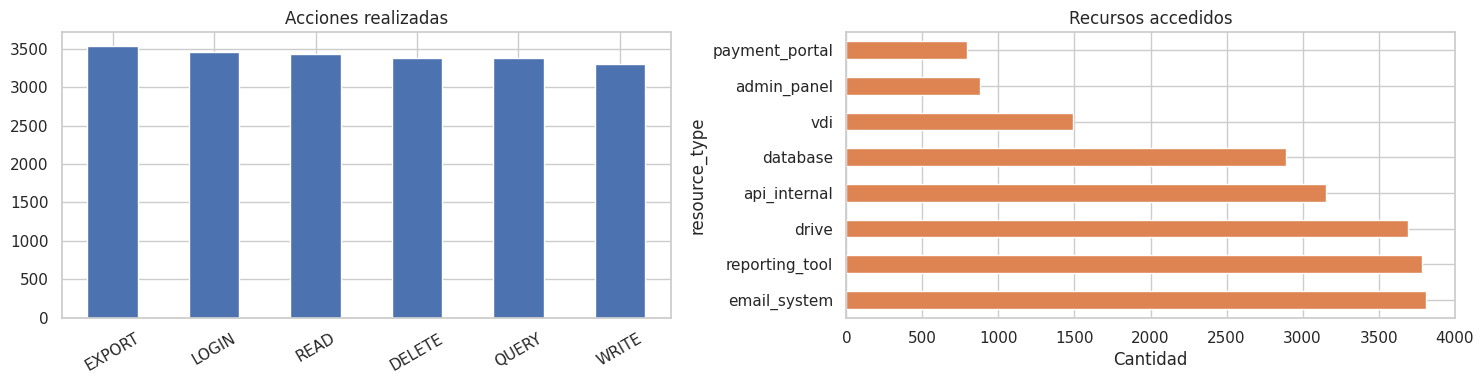

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

logs['action'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Acciones realizadas')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

logs['resource_type'].value_counts().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Recursos accedidos')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

### 4.3 Session duration — outliers

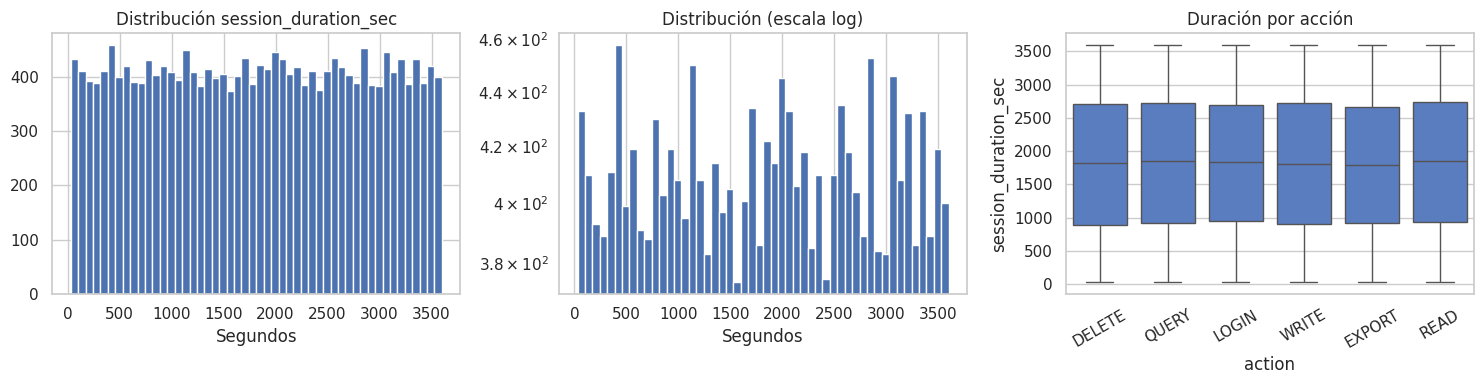

count    20495.0
mean      1814.9
std       1031.3
min         30.0
25%        921.0
50%       1826.0
75%       2705.0
max       3600.0
Name: session_duration_sec, dtype: float64

Outliers (> p99 = 3562s): 203 (0.99%)


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(logs['session_duration_sec'], bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución session_duration_sec')
axes[0].set_xlabel('Segundos')

axes[1].hist(logs['session_duration_sec'], bins=50, color='#4C72B0', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribución (escala log)')
axes[1].set_xlabel('Segundos')

sns.boxplot(data=logs, x='action', y='session_duration_sec', ax=axes[2])
axes[2].set_title('Duración por acción')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(logs['session_duration_sec'].describe().round(1))

p99 = logs['session_duration_sec'].quantile(0.99)
outliers = logs[logs['session_duration_sec'] > p99]
print(f'\nOutliers (> p99 = {p99:.0f}s): {len(outliers)} ({len(outliers)/len(logs)*100:.2f}%)')

### 4.4 Patrones temporales

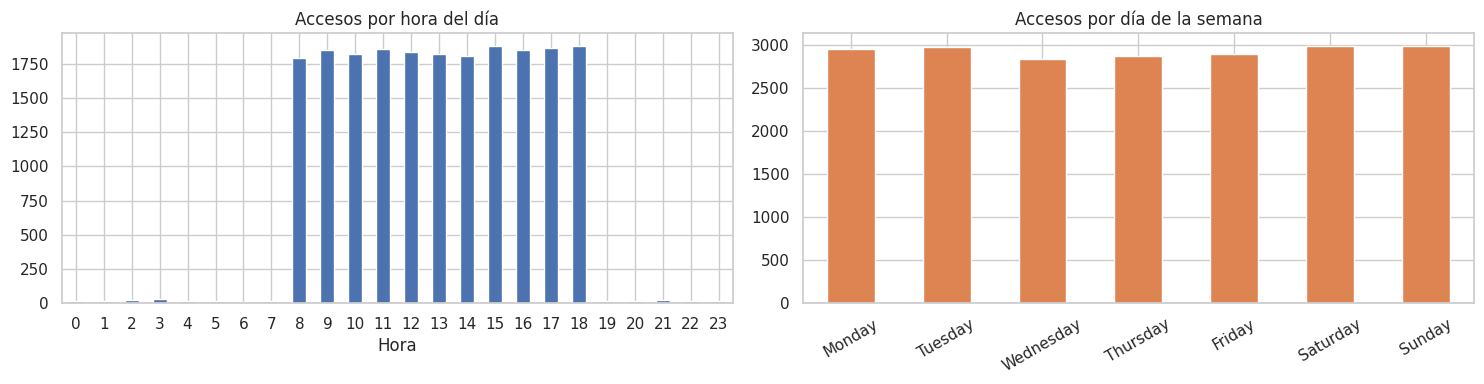

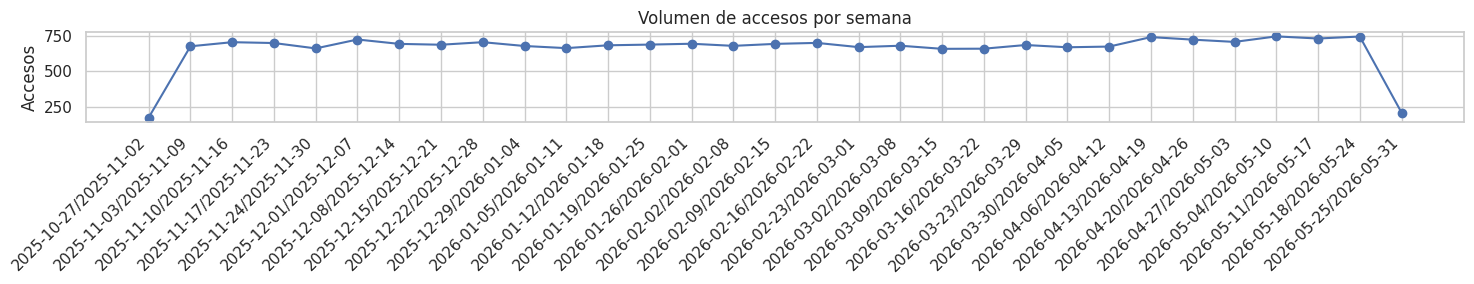

In [18]:
logs['hour'] = logs['timestamp'].dt.hour
logs['day_of_week'] = logs['timestamp'].dt.day_name()
logs['week'] = logs['timestamp'].dt.to_period('W')

DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

logs.groupby('hour').size().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Accesos por hora del día')
axes[0].set_xlabel('Hora')
axes[0].tick_params(axis='x', rotation=0)

logs.groupby('day_of_week').size().reindex(DOW_ORDER).plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Accesos por día de la semana')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Tendencia semanal
weekly = logs.groupby('week').size()
weekly.index = weekly.index.astype(str)
plt.figure(figsize=(15, 3))
plt.plot(weekly.index, weekly.values, marker='o', color='#4C72B0')
plt.xticks(rotation=45, ha='right')
plt.title('Volumen de accesos por semana')
plt.ylabel('Accesos')
plt.tight_layout()
plt.show()

### 4.5 Accesos en horario fuera de oficina (00h–06h)

In [19]:
after_hours = logs[logs['hour'].between(0, 5)]
print(f'Accesos fuera de horario (00-05h): {len(after_hours)} ({len(after_hours)/len(logs)*100:.1f}%)')
print(f'Usuarios distintos: {after_hours["user_id"].nunique()}')

# ¿Son internos o externos?
ah_users = after_hours[['user_id']].drop_duplicates().merge(users[['user_id', 'user_type', 'department']], on='user_id', how='left')
print('\nTipo de usuario en accesos fuera de horario:')
print(ah_users['user_type'].value_counts())

# Accesos en fin de semana
weekend = logs[logs['day_of_week'].isin(['Saturday', 'Sunday'])]
print(f'\nAccesos en fin de semana: {len(weekend)} ({len(weekend)/len(logs)*100:.1f}%)')

Accesos fuera de horario (00-05h): 127 (0.6%)
Usuarios distintos: 7

Tipo de usuario en accesos fuera de horario:
user_type
Internal    7
Name: count, dtype: int64

Accesos en fin de semana: 5968 (29.1%)


### 4.6 Accesos de usuarios inactivos

In [20]:
inactive_logs = logs[logs['user_id'].isin(inactive_users)]
print(f'Accesos de usuarios INACTIVOS: {len(inactive_logs)} ({len(inactive_logs)/len(logs)*100:.1f}%)')
print(f'Usuarios inactivos con accesos: {inactive_logs["user_id"].nunique()} de {len(inactive_users)} inactivos')

if len(inactive_logs) > 0:
    print('\nAcciones realizadas por inactivos:')
    print(inactive_logs['action'].value_counts())
    print('\nRecursos accedidos por inactivos:')
    print(inactive_logs['resource_type'].value_counts())

Accesos de usuarios INACTIVOS: 53 (0.3%)
Usuarios inactivos con accesos: 3 de 3 inactivos

Acciones realizadas por inactivos:
action
QUERY     13
EXPORT    11
LOGIN      9
READ       9
DELETE     6
WRITE      5
Name: count, dtype: int64

Recursos accedidos por inactivos:
resource_type
admin_panel       13
api_internal      12
reporting_tool     9
email_system       7
database           7
drive              3
vdi                2
Name: count, dtype: int64


---
## 5. Análisis cruzado — Señales de riesgo

### 5.1 Accesos sin permiso asignado

In [21]:
# Conjunto de (user_id, resource_id) con permiso asignado
perm_pairs = set(zip(perms['user_id'], perms['resource_id']))
logs['has_permission'] = logs.apply(lambda r: (r['user_id'], r['resource_id']) in perm_pairs, axis=1)

no_perm_logs = logs[~logs['has_permission']]
print(f'Accesos SIN permiso asignado: {len(no_perm_logs)} ({len(no_perm_logs)/len(logs)*100:.1f}%)')
print(f'Usuarios distintos:           {no_perm_logs["user_id"].nunique()}')

# Top usuarios por accesos sin permiso
top_noperm = no_perm_logs.groupby('user_id').size().nlargest(10)
print('\nTop 10 usuarios por accesos sin permiso:')
print(top_noperm.to_string())

Accesos SIN permiso asignado: 161 (0.8%)
Usuarios distintos:           4

Top 10 usuarios por accesos sin permiso:
user_id
USR0080    84
USR0060    27
USR0040    25
USR0041    25


### 5.2 Accesos sin permiso a recursos de alta criticidad

In [22]:
# Mapa resource_id → criticidad máxima asignada
resource_crit = perms.groupby('resource_id')['criticality'].max()
logs['resource_criticality'] = logs['resource_id'].map(resource_crit)

# Re-filtrar desde logs para incluir la nueva columna
no_perm_logs = logs[~logs['has_permission']]
high_crit_no_perm = no_perm_logs[no_perm_logs['resource_criticality'].isin(['HIGH', 'VERY_HIGH'])]
print(f'Accesos sin permiso a recursos HIGH/VERY_HIGH: {len(high_crit_no_perm)}')
print(f'Usuarios afectados: {high_crit_no_perm["user_id"].nunique()}')

print('\nPor criticidad:')
print(high_crit_no_perm['resource_criticality'].value_counts())

print('\nPor tipo de recurso:')
print(high_crit_no_perm['resource_type'].value_counts())

Accesos sin permiso a recursos HIGH/VERY_HIGH: 161
Usuarios afectados: 4

Por criticidad:
resource_criticality
HIGH         93
VERY_HIGH    68
LOW           0
MEDIUM        0
Name: count, dtype: int64

Por tipo de recurso:
resource_type
api_internal      84
vdi               29
payment_portal    25
admin_panel       14
database           9
Name: count, dtype: int64


### 5.3 Accesos con permiso expirado

In [23]:
# Cruce: acceso ocurrió después de que el permiso expiró
perms_exp = perms.dropna(subset=['expires_at'])[['user_id', 'resource_id', 'expires_at', 'criticality']]
merged = logs.merge(perms_exp, on=['user_id', 'resource_id'], how='inner')
expired_access = merged[merged['timestamp'] > merged['expires_at']]

print(f'Accesos realizados con permiso ya expirado: {len(expired_access)}')
print(f'Usuarios distintos: {expired_access["user_id"].nunique()}')
print('\nPor criticidad del permiso:')
print(expired_access['criticality'].value_counts())

Accesos realizados con permiso ya expirado: 93
Usuarios distintos: 2

Por criticidad del permiso:
criticality
HIGH         47
VERY_HIGH    20
LOW          13
MEDIUM       13
Name: count, dtype: int64


### 5.4 Volumen de accesos vs. peer group (departamento × rol)

In [24]:
user_access_count = logs.groupby('user_id').size().reset_index(name='access_count')
user_access_count = user_access_count.merge(users[['user_id', 'department', 'role', 'user_type']], on='user_id', how='left')

peer_stats = user_access_count.groupby(['department', 'role'])['access_count'].agg(
    peer_median='median', peer_std='std', peer_count='count'
).reset_index()

user_access_count = user_access_count.merge(peer_stats, on=['department', 'role'])
user_access_count['z_score'] = (
    (user_access_count['access_count'] - user_access_count['peer_median']) /
    user_access_count['peer_std'].replace(0, np.nan)
)

high_volume = user_access_count[user_access_count['z_score'] > 2].sort_values('z_score', ascending=False)
print(f'Usuarios con volumen anómalo vs. peers (z > 2): {len(high_volume)}')
print(high_volume[['user_id', 'department', 'role', 'access_count', 'peer_median', 'z_score']].head(15).to_string(index=False))

Usuarios con volumen anómalo vs. peers (z > 2): 9
user_id  department       role  access_count  peer_median  z_score
USR0020     Fintech       Reps           396         43.0 4.216122
USR0021     Fintech       Reps           395         43.0 4.204179
USR0080 Engineering   Engineer           114         53.0 4.080808
USR0070     Fintech    Analyst           295         40.5 3.696231
USR0060          HR    Analyst            34         16.0 2.904050
USR0040       Legal      Admin            42         11.5 2.743925
USR0443    Security Specialist            76         53.0 2.316817
USR0244 Engineering Specialist            71         51.0 2.037336
USR0402     Fintech    Manager            51         36.0 2.024359


### 5.5 Comparativa interno vs. externo

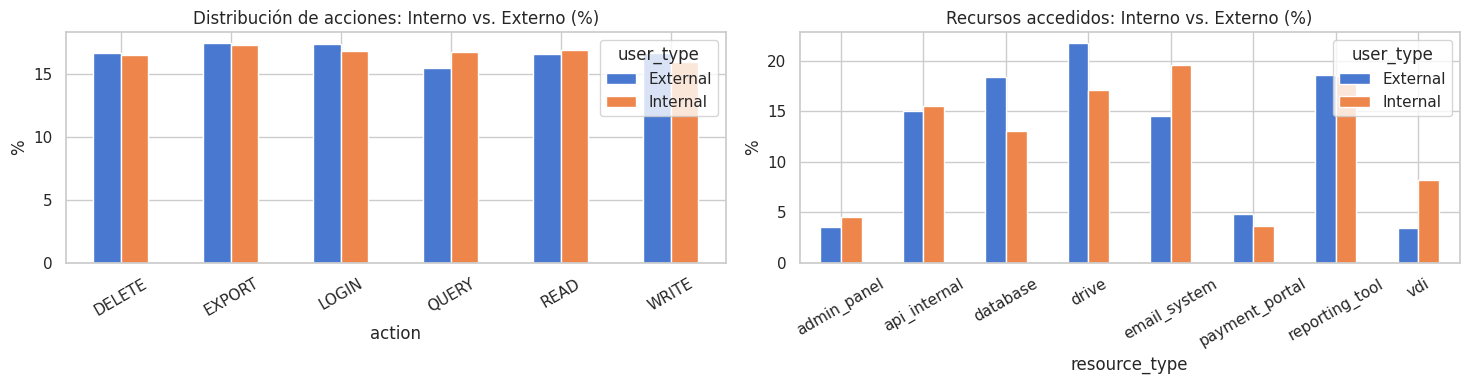

Acciones DELETE/EXPORT por usuarios EXTERNOS: 1400
action
EXPORT    716
DELETE    684
Name: count, dtype: int64


In [25]:
logs_with_type = logs.merge(users[['user_id', 'user_type']], on='user_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

action_by_type = pd.crosstab(logs_with_type['action'], logs_with_type['user_type'], normalize='columns') * 100
action_by_type.plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución de acciones: Interno vs. Externo (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=30)

resource_by_type = pd.crosstab(logs_with_type['resource_type'], logs_with_type['user_type'], normalize='columns') * 100
resource_by_type.plot(kind='bar', ax=axes[1])
axes[1].set_title('Recursos accedidos: Interno vs. Externo (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Acciones de alto riesgo por externos
high_risk_actions = ['DELETE', 'EXPORT']
ext_high_risk = logs_with_type[(logs_with_type['user_type'] == 'External') & 
                                (logs_with_type['action'].isin(high_risk_actions))]
print(f'Acciones DELETE/EXPORT por usuarios EXTERNOS: {len(ext_high_risk)}')
print(ext_high_risk['action'].value_counts())

### 5.6 Resumen de señales por usuario

In [26]:
# Tabla resumen de flags por usuario para orientar el scoring
all_users = users[['user_id', 'user_type', 'department', 'role', 'status']].copy()

# Flag 1: es usuario inactivo
all_users['is_inactive'] = all_users['status'] == 'Inactive'

# Flag 2: tiene accesos siendo inactivo
inactive_log_users = set(inactive_logs['user_id'])
all_users['inactive_with_accesses'] = all_users['user_id'].isin(inactive_log_users)

# Flag 3: accesos sin permiso
no_perm_users = no_perm_logs.groupby('user_id').size().reset_index(name='accesses_without_perm')
all_users = all_users.merge(no_perm_users, on='user_id', how='left').fillna({'accesses_without_perm': 0})

# Flag 4: accesos sin permiso a HIGH/VERY_HIGH
high_no_perm = high_crit_no_perm.groupby('user_id').size().reset_index(name='high_crit_no_perm')
all_users = all_users.merge(high_no_perm, on='user_id', how='left').fillna({'high_crit_no_perm': 0})

# Flag 5: volumen anómalo vs. peers
all_users = all_users.merge(user_access_count[['user_id', 'access_count', 'z_score']], on='user_id', how='left')
all_users['volume_anomaly'] = all_users['z_score'] > 2

# Conteo de flags activos
flag_cols = ['inactive_with_accesses', 'volume_anomaly']
all_users['flags_count'] = (
    (all_users['accesses_without_perm'] > 0).astype(int) +
    (all_users['high_crit_no_perm'] > 0).astype(int) +
    all_users['inactive_with_accesses'].astype(int) +
    all_users['volume_anomaly'].astype(int)
)

print('Distribución de flags por usuario:')
print(all_users['flags_count'].value_counts().sort_index())

print('\nTop 20 usuarios con más flags:')
top_flagged = all_users.sort_values(['flags_count', 'high_crit_no_perm'], ascending=False).head(20)
print(top_flagged[['user_id', 'user_type', 'department', 'role', 'status',
                    'accesses_without_perm', 'high_crit_no_perm', 'volume_anomaly',
                    'inactive_with_accesses', 'flags_count']].to_string(index=False))

Distribución de flags por usuario:
flags_count
0    487
1      9
2      1
3      3
Name: count, dtype: int64

Top 20 usuarios con más flags:
user_id user_type  department       role   status  accesses_without_perm  high_crit_no_perm  volume_anomaly  inactive_with_accesses  flags_count
USR0080  Internal Engineering   Engineer   Active                   84.0               84.0            True                   False            3
USR0060  Internal          HR    Analyst   Active                   27.0               27.0            True                   False            3
USR0040  Internal       Legal      Admin   Active                   25.0               25.0            True                   False            3
USR0041  Internal     Fintech Specialist   Active                   25.0               25.0           False                   False            2
USR0010  Internal    Security    Analyst Inactive                    0.0                0.0           False                    True   

---
## 6. Hipótesis documentadas

Basadas en el EDA anterior, estas son las hipótesis que guiarán el modelo de scoring:

### H1 — Acceso sin permiso es la señal más fuerte
Un usuario que accede a recursos para los que no tiene permiso registrado es una anomalía directa. Si esos recursos son `HIGH` o `VERY_HIGH`, el riesgo escala significativamente.

### H2 — Usuarios inactivos con accesos son críticos
Un usuario con `status = Inactive` no debería poder acceder a ningún recurso. Cualquier acceso de este tipo es una señal roja independientemente del recurso.

### H3 — Volumen anómalo vs. peers indica comportamiento sospechoso
Usuarios con un volumen de accesos 2+ desviaciones estándar por encima de su grupo de peers (mismo departamento y rol) merecen revisión. Puede indicar exfiltración de datos o cuenta comprometida.

### H4 — Acciones destructivas/exportación por externos son de alto riesgo
Usuarios externos realizando `DELETE` o `EXPORT` sobre recursos de alta criticidad es un patrón anómalo. Los externos deberían tener accesos más restringidos.

### H5 — Permisos expirados que siguen siendo usados
Si el sistema no revoca automáticamente permisos vencidos, un atacante o insider podría aprovecharlo. Los accesos post-expiración son señal de control de acceso deficiente.

### H6 — Accesos fuera de horario laboral (00h–06h)
Para usuarios internos, acceder a recursos críticos en horario nocturno es inusual. Para externos, puede ser normal dependiendo de la zona horaria, pero requiere contexto.

### H7 — Permisos VERY_HIGH sin expiración en usuarios externos
Un usuario externo con permiso permanente sobre recursos de criticidad muy alta es una configuración de riesgo por diseño.

In [27]:
# Validación rápida de H7
ext_vh_no_exp = perms[
    (perms['user_id'].isin(users[users['user_type'] == 'External']['user_id'])) &
    (perms['criticality'] == 'VERY_HIGH') &
    (perms['expires_at'].isna())
]
print(f'H7 — Usuarios externos con permiso VERY_HIGH sin expiración:')
print(f'  Permisos: {len(ext_vh_no_exp)} | Usuarios: {ext_vh_no_exp["user_id"].nunique()}')
print(ext_vh_no_exp['resource_type'].value_counts())

H7 — Usuarios externos con permiso VERY_HIGH sin expiración:
  Permisos: 24 | Usuarios: 20
resource_type
payment_portal    11
admin_panel        8
vdi                5
Name: count, dtype: int64
